# MFPT vs m0: Network and Reset Protocol Comparison (Julia)

This notebook compares MFPT as a function of m0 across network types and reset protocols,
using only the Julia package functions from src/VoterResetting.jl.

In [16]:
using Graphs
using Random
using Statistics
using Printf
using Plots

project_root = isdir(joinpath(pwd(), "src")) ? pwd() : dirname(dirname(pwd()))
include(joinpath(project_root, "src", "VoterResetting.jl"))
using .VoterResetting

# Use explicit imports to avoid name ambiguity with other loaded modules.
import .VoterResetting: ComplexParams, hub_reset, random_node_reset, first_passage_time_complex

figures_dir = joinpath(project_root, "figures", "complex")
mkpath(figures_dir)
println("Figures will be saved to: $figures_dir")

Figures will be saved to: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\complex


In [17]:
# Parameters
N = 500
r = 1
m0_values = collect(range(-0.9, 0.9, length=11))
nsamples = 1000
seed = 1234

Random.seed!(seed)

graphs = Dict(
    "ER" => erdos_renyi(N, 0.1),
    "RRG" => random_regular_graph(N, 6),
    "SF" => barabasi_albert(N, 2),
)

# Keep the 3-protocol comparison layout, now using uniform magnetization resetting.
protocols = [
    "High-degree reset" => :hub_high,
    "Low-degree reset"  => :hub_low,
    "Random-node reset" => :random_node,
]

println("Setup complete: N=$N, r=$r, points=$(length(m0_values)), nsamples=$nsamples")
println("Reset law: uniform magnetization at each reset event.")

Setup complete: N=500, r=1, points=11, nsamples=1000
Reset law: uniform magnetization at each reset event.


In [18]:
function mfpt_curve_vs_m0_complex(G, m0_values; r=0.1, nsamples=1000, protocol::Symbol=:hub_high)
    mfpt = zeros(length(m0_values))
    total = length(m0_values)
    t0 = time()

    for (i, m0) in enumerate(m0_values)
        params = VoterResetting.ComplexParams(r, Float64(m0))

        # Uniform resetting law: at each reset event sample magnetization uniformly in [-1, 1]
        # on the discrete grid m = 2n/N - 1.
        # We keep protocol labels for comparison continuity with previous plots.
        reset_protocol = VoterResetting.uniform_reset()

        out = VoterResetting.first_passage_time_complex(
            G,
            params;
            consensus_type=:positive,
            nsamples=nsamples,
            reset=reset_protocol,
        )
        mfpt[i] = out.mean_fpt

        elapsed = time() - t0
        rate = i / max(elapsed, 1e-9)
        eta = (total - i) / max(rate, 1e-9)
        @printf("[m0 %d/%d] m0=%.3f | MFPT=%.4f | elapsed=%.1fs | eta=%.1fs\n", i, total, m0, mfpt[i], elapsed, eta)
        flush(stdout)
    end

    return mfpt
end

mfpt_curve_vs_m0_complex (generic function with 1 method)

In [19]:
results = Dict{String, Dict{String, Vector{Float64}}}()

for (gname, G) in graphs
    results[gname] = Dict{String, Vector{Float64}}()
    for (pname, psym) in protocols
        println("Running: $gname | $pname")
        results[gname][pname] = mfpt_curve_vs_m0_complex(
            G,
            m0_values;
            r=r,
            nsamples=nsamples,
            protocol=psym,
        )
    end
end

println("All scans finished.")

Running: RRG | High-degree reset
[m0 1/11] m0=-0.900 | MFPT=1070.8495 | elapsed=6.9s | eta=68.6s
[m0 2/11] m0=-0.720 | MFPT=1008.1988 | elapsed=14.8s | eta=66.8s
[m0 3/11] m0=-0.540 | MFPT=930.0561 | elapsed=23.1s | eta=61.5s
[m0 4/11] m0=-0.360 | MFPT=756.6054 | elapsed=31.4s | eta=54.9s
[m0 5/11] m0=-0.180 | MFPT=740.3965 | elapsed=39.8s | eta=47.8s
[m0 6/11] m0=0.000 | MFPT=618.6253 | elapsed=48.0s | eta=40.0s
[m0 7/11] m0=0.180 | MFPT=562.2579 | elapsed=58.8s | eta=33.6s
[m0 8/11] m0=0.360 | MFPT=408.9314 | elapsed=65.5s | eta=24.6s
[m0 9/11] m0=0.540 | MFPT=318.2880 | elapsed=70.6s | eta=15.7s
[m0 10/11] m0=0.720 | MFPT=196.0158 | elapsed=73.7s | eta=7.4s
[m0 11/11] m0=0.900 | MFPT=107.4858 | elapsed=75.2s | eta=0.0s
Running: RRG | Low-degree reset
[m0 1/11] m0=-0.900 | MFPT=1092.8864 | elapsed=7.0s | eta=70.4s
[m0 2/11] m0=-0.720 | MFPT=991.3646 | elapsed=15.1s | eta=68.0s
[m0 3/11] m0=-0.540 | MFPT=864.4971 | elapsed=23.4s | eta=62.5s
[m0 4/11] m0=-0.360 | MFPT=786.1985 | elapse

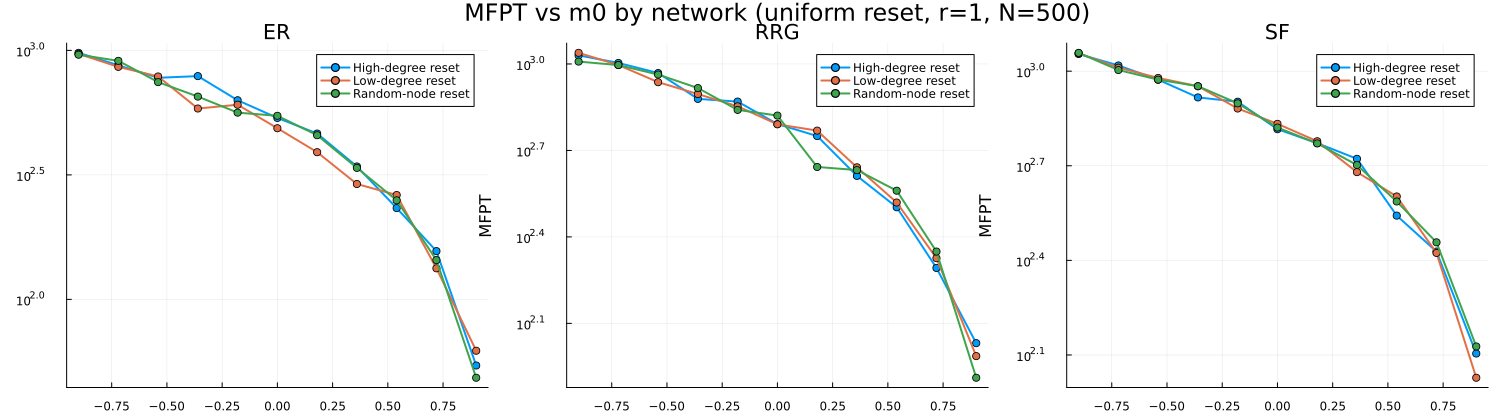

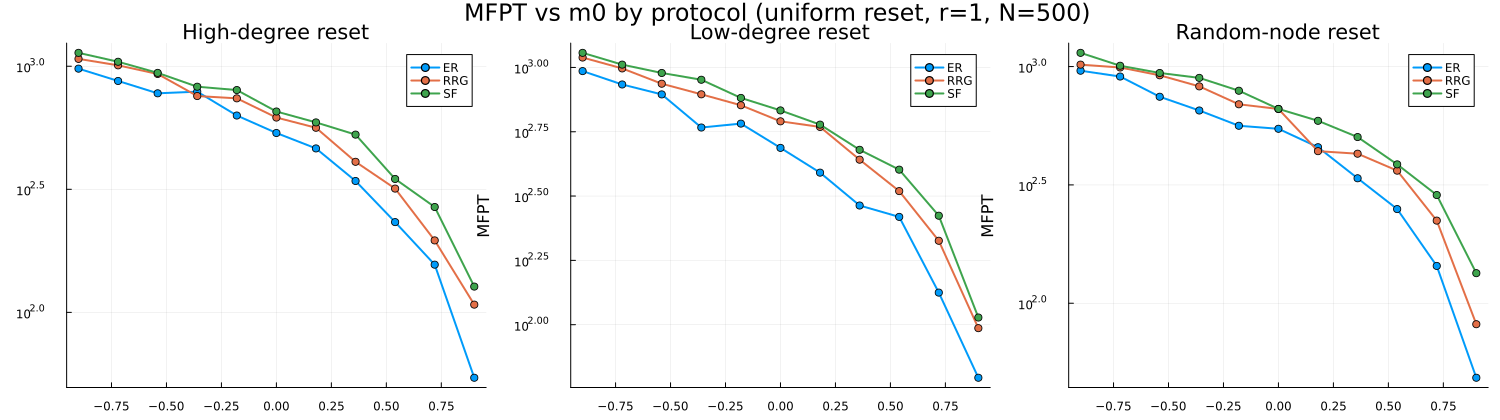

Saved Figure 1 to: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\complex\julia_mfpt_vs_m0_by_network_uniform.png
Saved Figure 2 to: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\figures\complex\julia_mfpt_vs_m0_uniform_by_network.png


In [21]:
network_names = ["ER", "RRG", "SF"]
protocol_names = [p[1] for p in protocols]

# Figure 1: protocol effect within each network
p1 = plot(layout=(1, length(network_names)), size=(1500, 420), legend=:topright, yscale=:log10)

for (idx, gname) in enumerate(network_names)
    for (pname, _) in protocols
        plot!(p1[idx], m0_values, results[gname][pname];
            lw=2, marker=:circle, label=pname)
    end
    xlabel!(p1[idx], "m0")
    ylabel!(p1[idx], "MFPT")
    title!(p1[idx], gname)
end

plot!(p1, plot_title="MFPT vs m0 by network (uniform reset, r=$r, N=$N)")
display(p1)

p1_path = joinpath(figures_dir, "julia_mfpt_vs_m0_by_network_uniform.png")
savefig(p1, p1_path)
println("Saved Figure 1 to: $p1_path")

# Figure 2: network effect within each protocol
p2 = plot(layout=(1, length(protocol_names)), size=(1500, 420), legend=:topright, yscale=:log10)

for (idx, (pname, _)) in enumerate(protocols)
    for gname in network_names
        plot!(p2[idx], m0_values, results[gname][pname];
            lw=2, marker=:circle, label=gname)
    end
    xlabel!(p2[idx], "m0")
    ylabel!(p2[idx], "MFPT")
    title!(p2[idx], pname)
end

plot!(p2, plot_title="MFPT vs m0 by protocol (uniform reset, r=$r, N=$N)")
display(p2)

p2_path = joinpath(figures_dir, "julia_mfpt_vs_m0_uniform_by_network.png")
savefig(p2, p2_path)
println("Saved Figure 2 to: $p2_path")